Basic settings

In [1]:
import os
import json
from math import floor, ceil

from utgc import GeographyManager, ConfigurationManager, precondition
import utgc.notebookhelper as nbh
from utgc.chain import CouponCollectorChain, coupon_collector_expectation
from gerrychain.chain import MarkovChain

params = nbh.get_notebook_params("us_house")

# Configuration files and example maps will be saved to a tagged directory
config_tag = params["prefix"] + ""  # <-- Match the tag used in notebook 01

In [2]:
# Load the configuration that was saved during notebook 01 (configure_sampling).
cfg = ConfigurationManager.from_config(f"output/{config_tag}/testrun/config.yaml")

# Data file path
geo = GeographyManager(
    pop_data={
        params["data_tag"]: {
            "data": params["data_path"],
            "transitability": params["transitability_path"],
        }
    },
    crs="EPSG:26912",
)
geo.fill_empty_ids(params["data_tag"], ["MUNIID"])

initial_plan = params["init_plan_path"]
num_districts = nbh.get_district_count(initial_plan)
print(f"Number of districts: {num_districts}")

# Build election dictionaries from the geospatial columns.
election_dicts = geo.build_election_dicts(
    params["data_tag"],
    years=[2016, 2020, 2024],
    offices=["PRE", "GOV", "ATG", "AUD", "TRE"],
    parties=["D", "R", "-"],
    overrides={"2024GOV": {"R1": "G24GOVRHEN", "R2": "G24GOVNCLA"}},
)

cfg = (cfg
    .add_election_updaters(elections=election_dicts, skip_if_missing_parties=True)
    .add_election_aggregator(
        name="sb1011_data",
        elections=[
            "2016PRE", "2016GOV", "2016ATG", "2016AUD", "2016TRE",
            "2020PRE", "2020GOV", "2020ATG",
            "2024PRE", "2024GOV", "2024ATG", "2024AUD", "2024TRE",
        ],
        parties=["D", "R", "-"],
    )
    .add_election_metric_updaters(
        "sb1011_data",
        [
            "partisan_bias_utah", "partisan_bias", "mean_median",
            "efficiency_gap", "stdev_partisan_share",
            "majority_partisan_shares", "majority_seats",
        ],
    )
)

Number of districts: 4


In [3]:
import utgc.plotting as gcplt

munis, counties = nbh.load_boundaries_from_shapefiles()

run_name = "ensemble"
save_dir = f"output/{config_tag}/{run_name}"
os.makedirs(os.path.join(save_dir, "maps"), exist_ok=True)

# Serializable, analysis-relevant updaters to write to output.jsonl.
# Excludes intermediates: population, pop_dev, perimeter, area,
# ls_muni, ls_county, sb1011_data_table, sb1011_data, raw election updaters.
output_updaters = {
    "split_muni", "split_county", "muni_multi_splits", "county_multi_splits",
    "assignment_hash", "polsby_popper",
    "majority_partisan_shares", "stdev_partisan_share", "efficiency_gap",
    "mean_median", "partisan_bias", "partisan_bias_utah", "majority_seats",
}
print(f"Output will be saved to {save_dir}")

Loaded 29 counties from data/bounds/UtahCountyBoundaries/ut_cnty_2020_bound.shp
Loaded 259 municipalities from data/bounds/UtahMunicipalBoundaries/Municipalities.shp
Output will be saved to output/us_house/ensemble


In [4]:
from gerrychain.accept import always_accept

initial_partition = geo.build_partition(
    pop_key=params["data_tag"],
    plan=initial_plan,
    updaters=cfg.updaters,
)
total_pop = sum(initial_partition["population"].values())
pop_tolerance = params["pop_tolerance"]

num_steps = 10
proposal = cfg.proposal(
    initial_partition,
    total_population=total_pop,
    pop_tolerance=pop_tolerance,
    edge_weights=geo.get_edge_weights(params["data_tag"]),
)
chain = CouponCollectorChain(
    proposal=proposal,
    constraints=cfg.constraints,
    accept=always_accept,
    initial_state=initial_partition,
    micro_steps_per_yield=ceil(coupon_collector_expectation(num_districts)),
    num_macro_steps=num_steps,
)

print(f"=== MCMC {run_name} ===")
print("Running Markov chain (Batched/Coupon Collector)...")
partition_iterator = chain.with_progress_bar()

output_path = os.path.join(save_dir, "output.jsonl")
assignments_path = os.path.join(save_dir, "assignments.jsonl")
with open(output_path, "w") as f:
    for step_number, partition in enumerate(partition_iterator):
        # Save metrics (output_updaters subset only)
        data = {"step": step_number}
        for name in output_updaters:
            if name not in cfg.updaters:
                continue
            value = partition[name]
            if isinstance(value, dict):
                data[name] = {str(k): v for k, v in sorted(value.items())}
            else:
                data[name] = value
        f.write(json.dumps(data) + "\n")
        f.flush()

        nbh.save_partition(
            partition,
            os.path.join(save_dir,"maps","shapefiles",f"step_{step_number:05d}.zip"),
            geo.get_pop_geodata(params["data_tag"])
        )

        # Plot ordinary map
        gcplt.visualize_partition(
            partition, step_number, os.path.join(save_dir, "maps"),
            counties=counties, municipalities=munis,
            split_munis_count=partition["split_muni"],
            split_counties_count=partition["split_county"],
        )
        # Plot map with partisanship
        gcplt.visualize_partition(
            partition, step_number, os.path.join(save_dir, "maps", "partisanship"),
            counties=counties, municipalities=munis,
            split_munis_count=partition["split_muni"],
            split_counties_count=partition["split_county"],
            color_by="majority_partisan_shares",
            colormap="coolwarm"
        )
        partition.parent = None
print("Done.")

=== MCMC ensemble ===
Running Markov chain (Batched/Coupon Collector)...


  0%|          | 0/10 [00:00<?, ?it/s]

Done.


In [5]:
def compute_metrics_for_map(shapefile_path, geo, cfg, pop_key=params["data_tag"]):
    """Return a dict of output_updater values for a given electoral map."""
    partition = geo.build_partition(
        pop_key=pop_key,
        plan=shapefile_path,
        updaters=cfg.updaters,
    )
    result = {}
    for name in output_updaters:
        if name not in cfg.updaters:
            continue
        value = partition[name]
        if isinstance(value, dict):
            result[name] = {str(k): v for k, v in sorted(value.items())}
        else:
            result[name] = value
    return result

comparison_maps = {
    "Map C": compute_metrics_for_map(
        "maps/US-House/2025_USH_Leg-C/2025_USH_Leg-C.shp", geo, cfg
    ),
    "Plaintiff 1": compute_metrics_for_map(
        "maps/US-House/2025_USH_Plaintiff-1/2025_USH_Plaintiff-1.shp", geo, cfg
    ),
    "Plaintiff 2": compute_metrics_for_map(
        "maps/US-House/2025_USH_Plaintiff-2/2025_USH_Plaintiff-2.shp", geo, cfg
    ),
    "2021 Enacted": compute_metrics_for_map(
        "maps/US-House/2021_USH_Enacted/2021_USH_Enacted.shp", geo, cfg
    ),
    "UIRC Orange": compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Orange/2021_USH_UIRC-Orange.shp", geo, cfg
    ),
    "UIRC Purple": compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Purple/2021_USH_UIRC-Purple.shp", geo, cfg
    ),
    "UIRC Public": compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Public/2021_USH_UIRC-Public.shp", geo, cfg
    ),
}

with open(f"output/{config_tag}/ensemble/comparison_maps.json", "w") as f:
    json.dump(comparison_maps, f, indent=2)

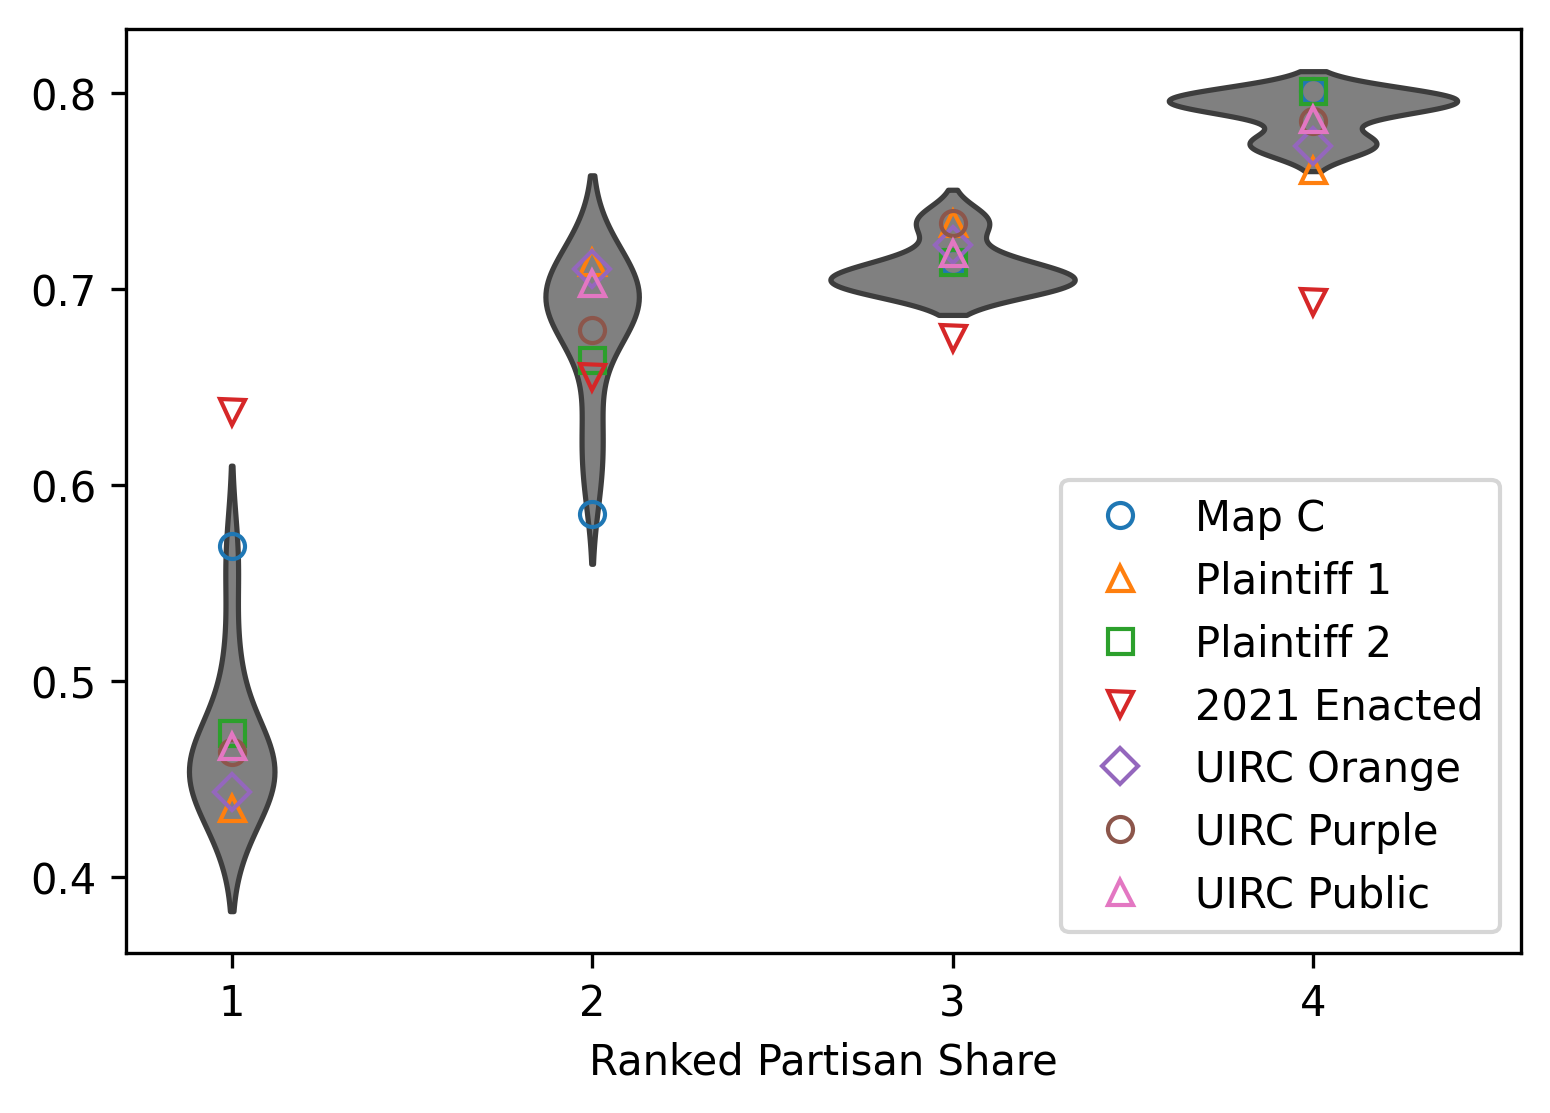

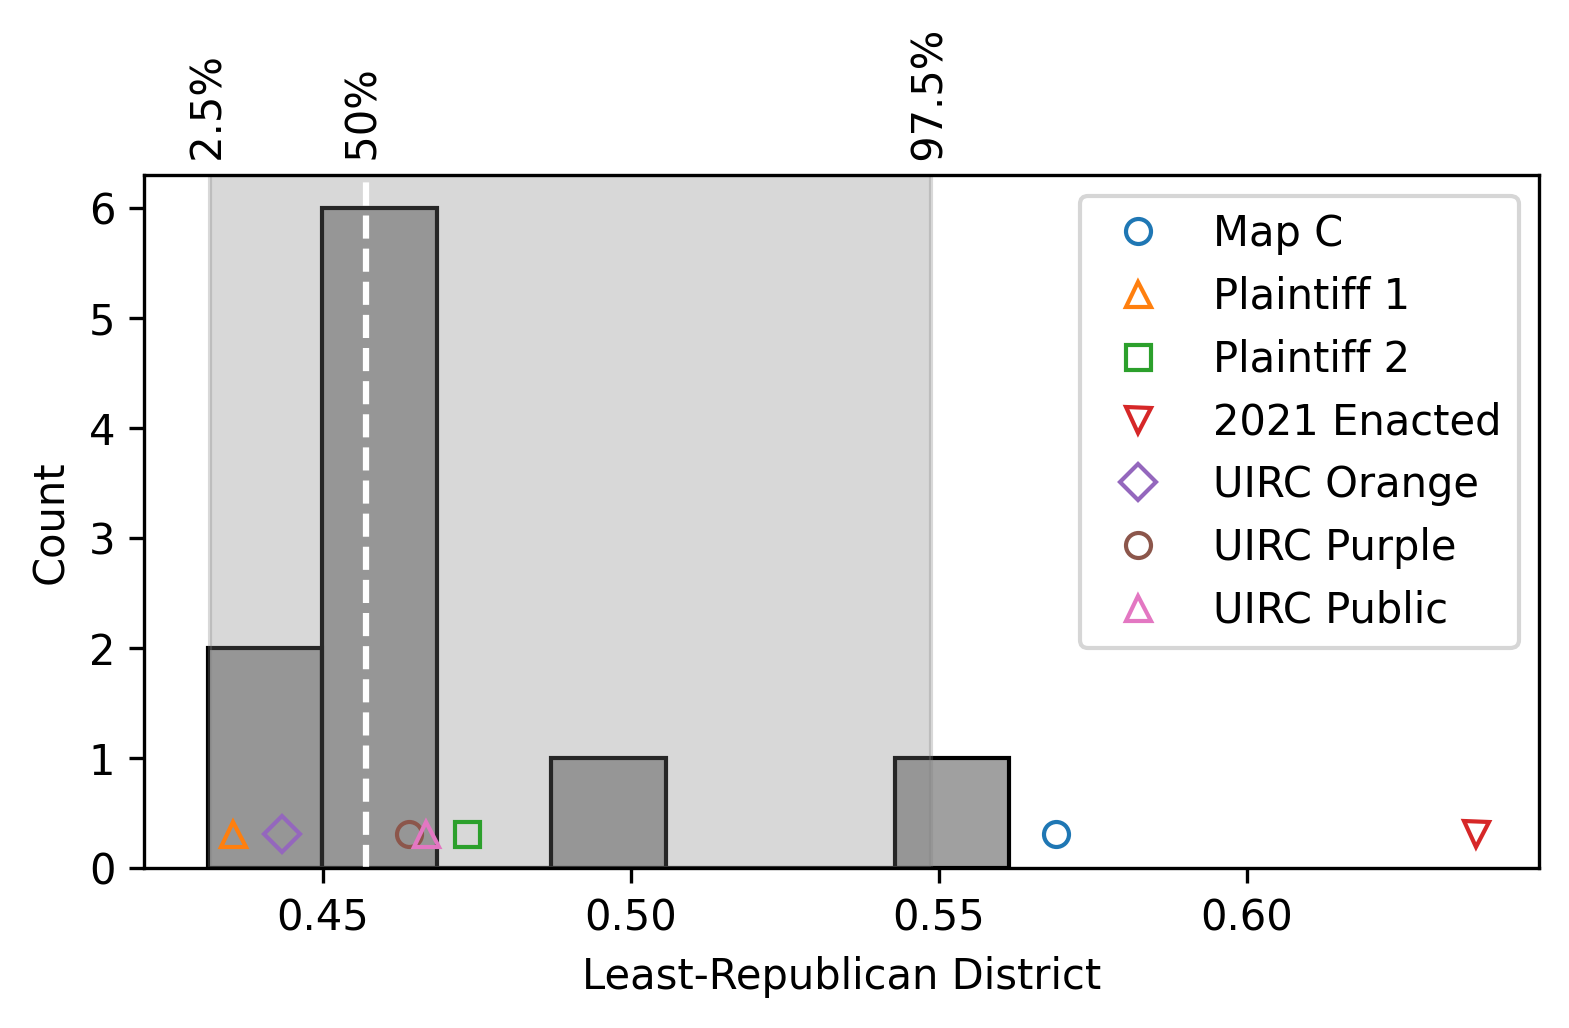

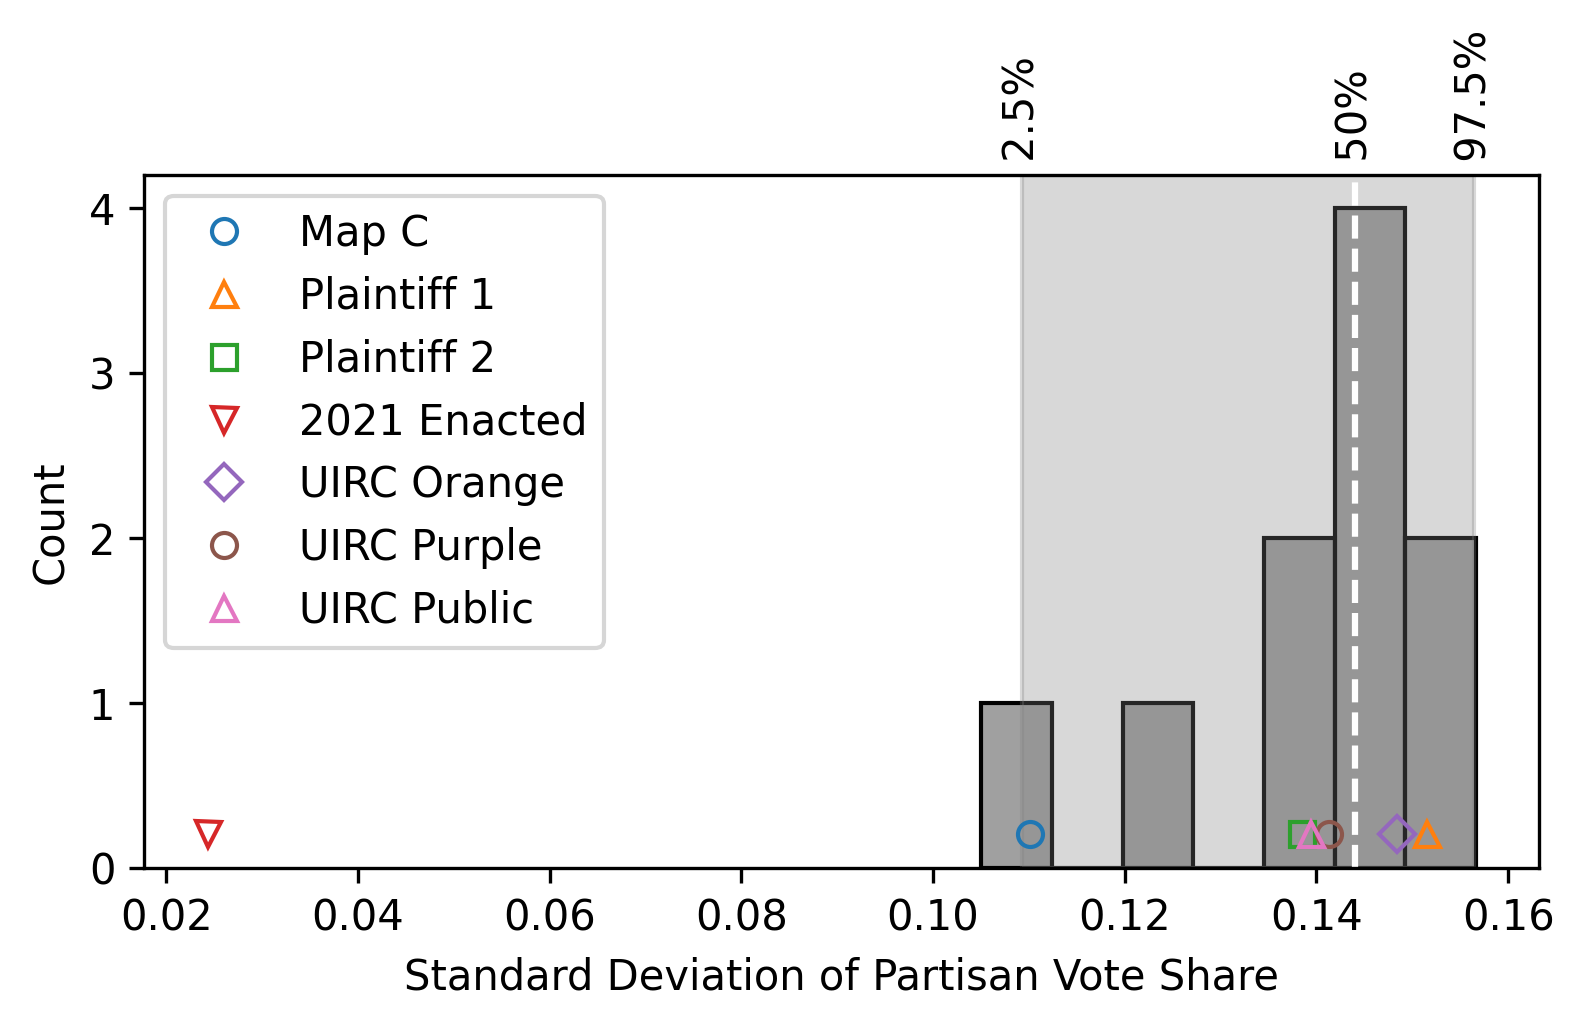

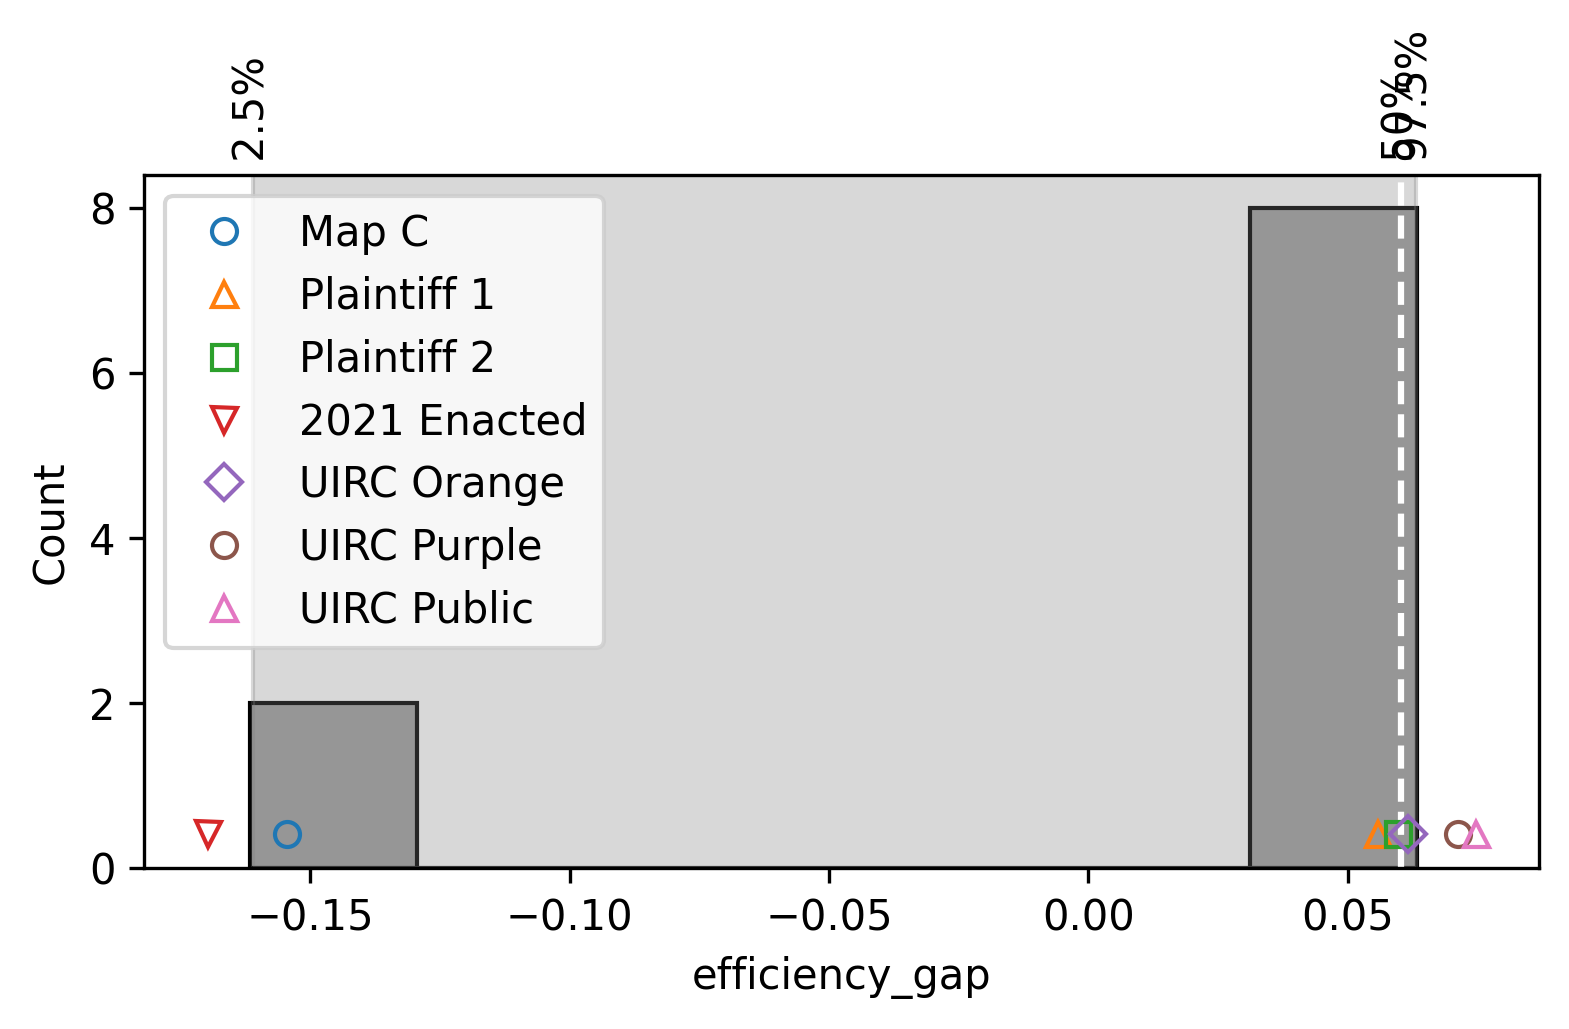

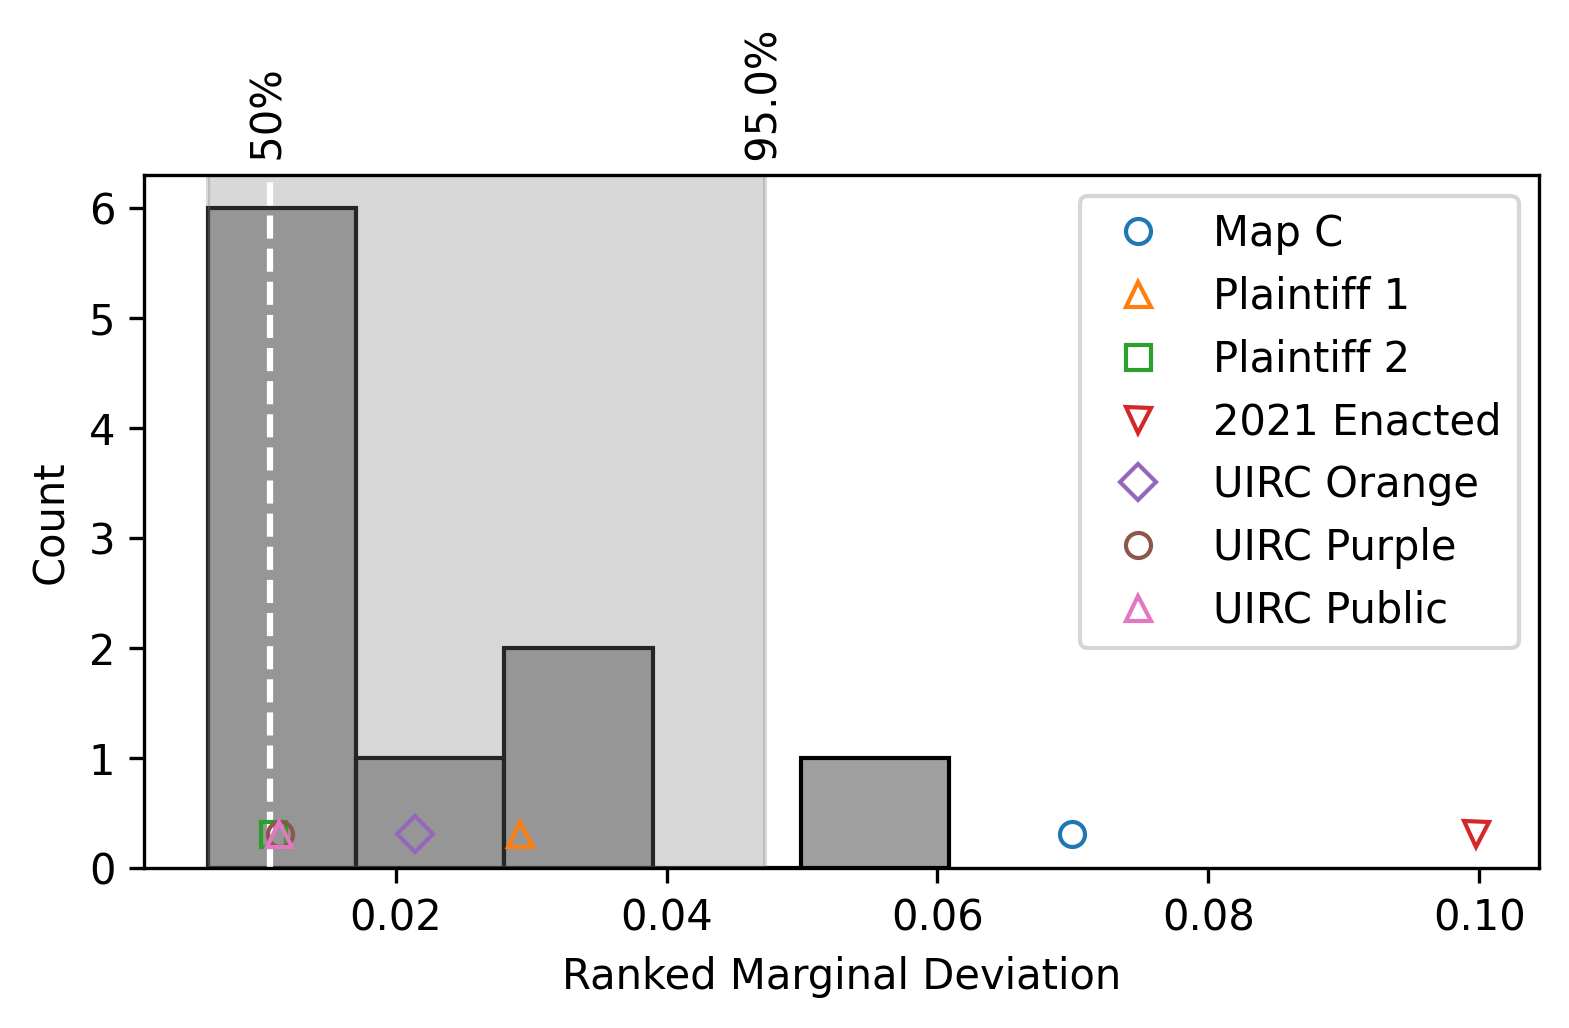

In [10]:
import utgc.results as gcres
import utgc.plotting as gcplt
import matplotlib.pyplot as plt

import json

if "comparison_maps" not in locals():
    with open(f"output/{config_tag}/ensemble/comparison_maps.json", "r") as f:
        comparison_maps = json.load(f)

output_path = f"output/{config_tag}/ensemble/output.jsonl"

# Partisan vote shares
party_shares = gcres.read_jsonl_table(output_path, "majority_partisan_shares")
party_shares = gcres.sort_subentries(party_shares, "majority_partisan_shares")

plt.figure(dpi=300, figsize=(6,4))
gcplt.district_plot(
    party_shares,
    reference_values={
        k: sorted(v["majority_partisan_shares"].values()) for k, v in comparison_maps.items()
    },
    relative_to_median=False
)
plt.xlabel("Ranked Partisan Share")
plt.show()

plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    party_shares["majority_partisan_shares_0"],
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: min(stats["majority_partisan_shares"].values())
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.xlabel("Least-Republican District")
plt.show()

sdvs = gcres.read_jsonl_table(output_path, "stdev_partisan_share")
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    sdvs["stdev_partisan_share"],
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: stats["stdev_partisan_share"]
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.xlabel("Standard Deviation of Partisan Vote Share")
plt.show()

eg = gcres.read_jsonl_table(output_path, "efficiency_gap")
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    eg["efficiency_gap"],
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: stats["efficiency_gap"]
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.show()

ranked_means = party_shares.mean(axis=0)

def ranked_marginal_deviation(party_shares, ranked_means):
    rmd = ((party_shares - ranked_means) ** 2)
    if isinstance(party_shares, list):
        rmd = rmd.sum()
    else:
        rmd = rmd.sum(axis=1)
    return (rmd / len(ranked_means)) ** 0.5

plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    ranked_marginal_deviation(party_shares, ranked_means),
    reference_values={
        mapname: ranked_marginal_deviation(
            sorted(stats["majority_partisan_shares"].values()),
            ranked_means
        ) for mapname, stats in comparison_maps.items()
    },
    highlight_interval=[0, 0.95],
    relative_to_median=False,
)
plt.xlabel("Ranked Marginal Deviation")
# plt.xlim(left=0)
plt.show()

In [7]:
hashes = gcres.read_jsonl_table(output_path, "assignment_hash")
print(f"Unique maps: {len(hashes.drop_duplicates()) / len(hashes):.1%}")

Unique maps: 100.0%
